In [1]:
import pandas as pd
df = pd.read_csv('./data/AB_Test_Results.csv')
print(df.head())

   USER_ID VARIANT_NAME  REVENUE
0      737      variant      0.0
1     2423      control      0.0
2     9411      control      0.0
3     7311      control      0.0
4     6174      variant      0.0


In [2]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   USER_ID       10000 non-null  int64  
 1   VARIANT_NAME  10000 non-null  object 
 2   REVENUE       10000 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 234.5+ KB


,USER_ID,REVENUE
count,10000.000000,10000.000000
mean,4981.080200,0.099447
std,2890.590115,2.318529
min,2.000000,0.000000
25%,2468.750000,0.000000
50%,4962.000000,0.000000
75%,7511.500000,0.000000
max,10000.000000,196.010000


In [14]:
group_df = df.groupby(['USER_ID','VARIANT_NAME'])['REVENUE'].sum().reset_index()

In [15]:
group_df.groupby('VARIANT_NAME').size()

VARIANT_NAME
control    3931
variant    3934
dtype: int64

<Axes: xlabel='REVENUE', ylabel='Density'>

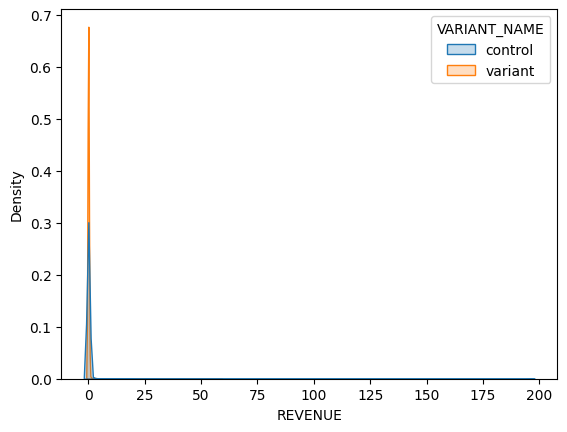

In [16]:
import seaborn as sns
sns.kdeplot(
    data=group_df,
    x="REVENUE",
    hue="VARIANT_NAME",
    fill=True
)

<Axes: xlabel='VARIANT_NAME', ylabel='REVENUE'>

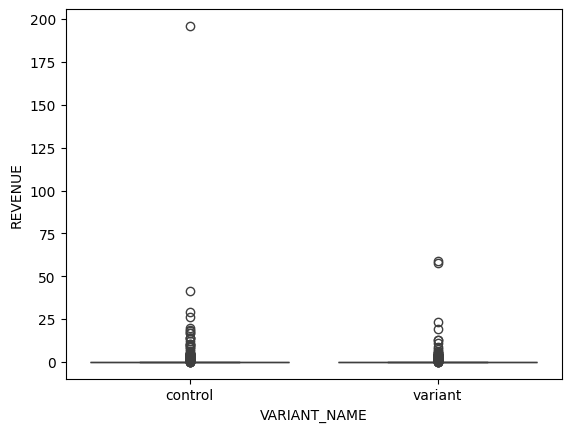

In [17]:
sns.boxplot(data=group_df, x='VARIANT_NAME', y='REVENUE')

In [18]:
group_df.groupby('VARIANT_NAME')['REVENUE'].mean()

VARIANT_NAME
control    0.163572
variant    0.089342
Name: REVENUE, dtype: float64

## Test Conversion Rate using Z Test

In [19]:
group_df['converted'] = (group_df['REVENUE']>0).astype(int)

In [20]:
from statsmodels.stats.proportion import proportions_ztest
total = group_df.groupby('VARIANT_NAME')['converted'].count()
success = group_df.groupby('VARIANT_NAME')['converted'].sum()
z_stat, p_value = proportions_ztest(success, total)
print(f"Z-statistic: {z_stat}, P-value: {p_value}")

Z-statistic: 0.7442761379156507, P-value: 0.4567094342624727


## Bootstraping / Mann Whiteney for Revenue / log revenue then do t test (can segment only spenders)

In [30]:
import numpy as np
converted_df = group_df[group_df['converted']==1]
control = converted_df[converted_df['VARIANT_NAME']=='control']['REVENUE'].values
treatment = converted_df[converted_df['VARIANT_NAME']=='variant']['REVENUE'].values
n_boot = 5000
diffs = []
for _ in range(n_boot):
    c = np.random.choice(control, size=len(control), replace=True)
    t = np.random.choice(treatment, size=len(treatment), replace=True)
    diffs.append(t.mean() - c.mean())
diffs = np.array(diffs)
lower = np.percentile(diffs, 2.5)
upper = np.percentile(diffs, 97.5)
p_value = (np.sum(diffs>=0) + 1) / (len(diffs)+1)
print(f"95% CI for the difference in mean revenue: [{lower}, {upper}]")
print(f"P-value: {p_value}")

95% CI for the difference in mean revenue: [-9.228575748239434, 1.3952978433098575]
P-value: 0.10937812437512498


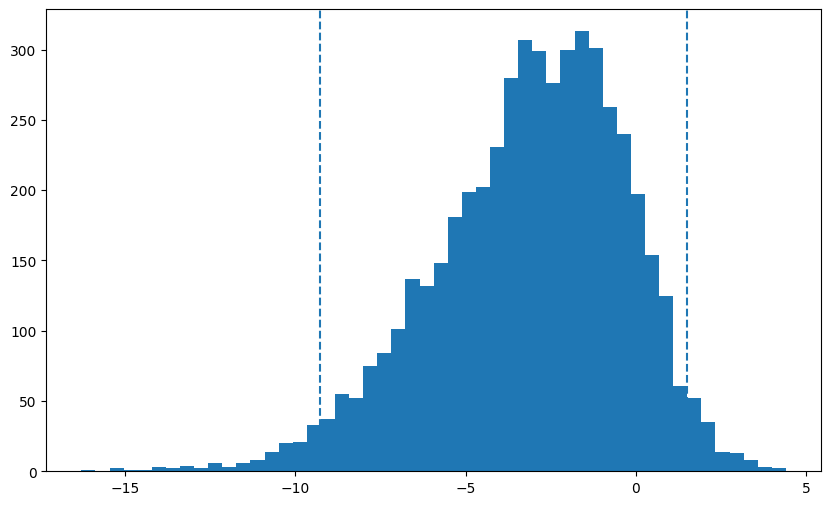

In [24]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.hist(diffs, bins=50)
plt.axvline(lower, linestyle='--')
plt.axvline(upper, linestyle='--')
plt.show()

## Mann Whitney Check

In [26]:
from scipy.stats import mannwhitneyu
u_stat, p_value = mannwhitneyu(control, treatment, alternative='two-sided')
print(f"Mann-Whitney U statistic: {u_stat}, P-value: {p_value}")

Mann-Whitney U statistic: 3273.0, P-value: 0.10678659163407059


## Log Transform T Test

/var/folders/01/fn6y_26n2kg0vjzvh7y6cjm80000gn/T/ipykernel_60912/871653212.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  converted_df['log_revenue'] = np.log1p(converted_df['REVENUE'])


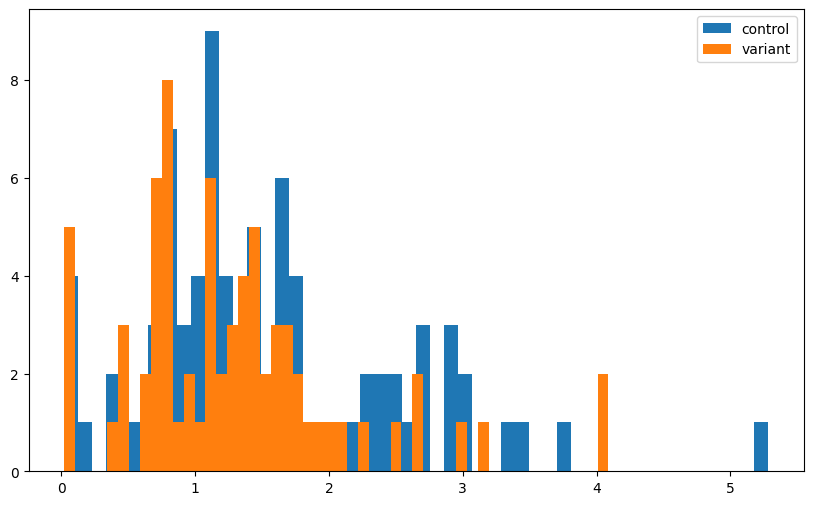

In [32]:
group_df['log_revenue'] = np.log1p(group_df['REVENUE'])
converted_df['log_revenue'] = np.log1p(converted_df['REVENUE'])
plt.figure(figsize=(10,6))
for grp in ['control','variant']:
    subset = converted_df[converted_df['VARIANT_NAME']==grp]['log_revenue']
    plt.hist(subset, bins=50,label=grp)
plt.legend()
plt.show()

In [33]:
from scipy.stats import ttest_ind
control = converted_df[converted_df['VARIANT_NAME']=='control']['log_revenue']
treatment = converted_df[converted_df['VARIANT_NAME']=='variant']['log_revenue']
t_stat, p_value = ttest_ind(control, treatment, equal_var=False)
print(f"T-statistic: {t_stat}, P-value: {p_value}")

T-statistic: 1.6537309710354615, P-value: 0.100288209240272
